# Task 1: Bank Customer Churn Prediction using Artificial Neural Network

## Overview
Build an Artificial Neural Network (ANN) to predict customer churn in a banking dataset. This task involves:
- Preprocessing the Banking dataset by removing unnecessary features
- Encoding categorical variables
- Building a Sequential ANN using Keras
- Training and evaluating using accuracy and confusion matrix metrics

## Dataset
- **File**: `data/Churn_Modeling.csv`
- **Target**: `Exited` (1 = churned, 0 = stayed)

## Rubric Coverage
1. Data Preprocessing (8 pts)
2. Building the Model (8 pts)
3. Model Training with Hyperparameter Experimentation (8 pts)
4. Model Evaluation (8 pts)
5. Visualization and Reporting (8 pts)

# 1. Imports and Setup

## Standard Imports

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Sklearn imports for preprocessing and evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.1


## Setup local lib files
- If using Google Colab upload lib files to Colab session
- Create a helper to reload lib modules after code changes

In [2]:
# === COLAB BOOTSTRAP ===
BOOTSTRAP_URL = 'https://raw.githubusercontent.com/rlogwood/fs-ml-lib/main/colab_bootstrap.py'
import urllib.request; exec(urllib.request.urlopen(BOOTSTRAP_URL).read().decode())
# === END BOOTSTRAP ===
# to force reload after code changes use force_refresh=True
upload_lib(force_refresh=False)

Not in Colab, using local lib files


## public git repo fs-ml-lib imports after any needed colab setup
`https://github.com/rlogwood/fs-ml-lib.git`

In [3]:
# Imports
import lib.text_util as tu
import lib.wrangler as wr
import lib.data_cleaner as dc
import lib.analyzer as da
import lib.corr_analysis as ca
import lib.utility as utl
import lib.data_downloader as ddl

# Reload modules after code changes
reload_lib_modules()

  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader


## Download any missing data files from Google Drive

In [4]:
# Unit 4 Incremental Capstone Google Drive Data Files
FOLDER_ID = "1WJUxYQNtlGy1q5EQjIjRuo2SFxVW9ivC?usp=sharing"

# Files expected to be found in Google drive data folder
#ALL_FILES = ['Churn_Modeling.csv','DENTAL_1.NPZ','Face_mask_detection.zip','GrammarandProductReviews.xlsx']
EXPECTED_FILES = ['Churn_Modeling.csv']

# colab data direcotry
DATA_DIR = ddl.get_data_dir()
ddl.ensure_data_available(FOLDER_ID, EXPECTED_FILES)

'./data'

# 2. Data Preprocessing (Rubric Task 1: 8 pts)

**Objectives:**
- Load and explore the dataset
- Remove unnecessary features (RowNumber, CustomerId, Surname)
- Encode categorical variables (Geography, Gender)
- Normalize numerical features using StandardScaler
- Create training and test splits

## 2.1 Load and Explore Data

In [5]:
# Load the dataset
df = pd.read_csv('data/Churn_Modeling.csv')

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Check data types and missing values
print("DATA TYPES")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

DATA TYPES
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

MISSING VALUES
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing values: 0


In [7]:
# Statistical summary
print("STATISTICAL SUMMARY")
print("="*60)
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Target variable distribution
print("TARGET VARIABLE DISTRIBUTION (Exited)")
print("="*60)
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.2f}%")

# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['Exited'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Exited (0 = Stayed, 1 = Churned)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
for i, v in enumerate(df['Exited'].value_counts()):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nNote: Dataset is imbalanced - {df['Exited'].value_counts()[0]/len(df)*100:.1f}% stayed vs {df['Exited'].value_counts()[1]/len(df)*100:.1f}% churned")


Note: Dataset is imbalanced - 79.6% stayed vs 20.4% churned


## 2.2 Remove Unnecessary Features

The following columns are removed as they don't contribute to churn prediction:
- **RowNumber**: Just an index
- **CustomerId**: Unique identifier with no predictive value
- **Surname**: Customer name has no bearing on churn

In [9]:
# Drop unnecessary columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)

print(f"Original shape: {df.shape}")
print(f"After dropping {columns_to_drop}: {df_clean.shape}")
print("\nRemaining columns:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i}. {col}")

Original shape: (10000, 14)
After dropping ['RowNumber', 'CustomerId', 'Surname']: (10000, 11)

Remaining columns:
  1. CreditScore
  2. Geography
  3. Gender
  4. Age
  5. Tenure
  6. Balance
  7. NumOfProducts
  8. HasCrCard
  9. IsActiveMember
  10. EstimatedSalary
  11. Exited


## 2.3 Encode Categorical Variables

We have two categorical columns:
- **Geography**: France, Spain, Germany (One-Hot Encoding)
- **Gender**: Male, Female (Binary Encoding)

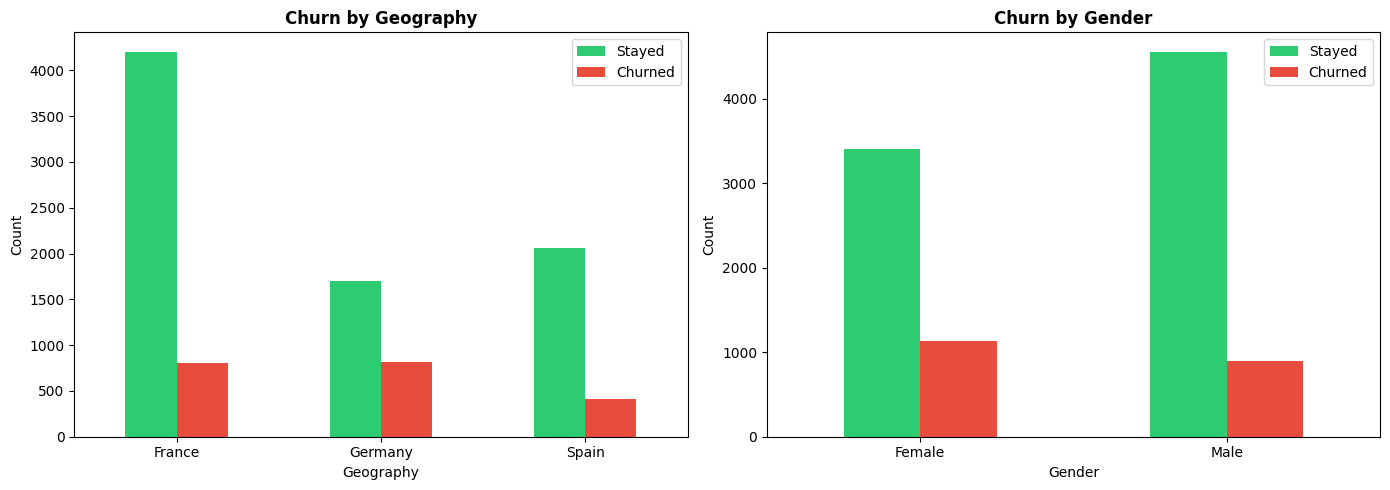

In [10]:
# Check categorical columns
print("CATEGORICAL VARIABLES")
print("="*60)
print(f"Geography unique values: {df_clean['Geography'].unique()}")
print(f"Gender unique values: {df_clean['Gender'].unique()}")

# Visualize categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geography distribution by churn
pd.crosstab(df_clean['Geography'], df_clean['Exited']).plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn by Geography', fontweight='bold')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Count')
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=0)

# Gender distribution by churn
pd.crosstab(df_clean['Gender'], df_clean['Exited']).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['Stayed', 'Churned'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Encode Gender using Label Encoding (binary: Male=1, Female=0)
label_encoder = LabelEncoder()
df_clean['Gender'] = label_encoder.fit_transform(df_clean['Gender'])
print(f"Gender encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# One-Hot Encode Geography (3 categories -> 2 dummy variables to avoid multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

print(f"\nShape after encoding: {df_encoded.shape}")
print("\nColumns after encoding:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i}. {col}")
    
df_encoded.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## 2.4 Feature Scaling and Train/Test Split

- Separate features (X) and target (y)
- Split into training (80%) and testing (20%) sets
- Apply StandardScaler to normalize features (critical for neural networks)

In [12]:
# Separate features and target
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Features shape: (10000, 11)
Target shape: (10000,)

Feature columns (11):
  1. CreditScore
  2. Gender
  3. Age
  4. Tenure
  5. Balance
  6. NumOfProducts
  7. HasCrCard
  8. IsActiveMember
  9. EstimatedSalary
  10. Geography_Germany
  11. Geography_Spain


In [13]:
# Split into training and testing sets (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("TRAIN/TEST SPLIT")
print("="*60)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())

TRAIN/TEST SPLIT
Training set size: 8000 samples (80%)
Testing set size: 2000 samples (20%)

Training target distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

Testing target distribution:
Exited
0    1593
1     407
Name: count, dtype: int64


In [14]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("FEATURE SCALING (StandardScaler)")
print("="*60)
print(f"Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Testing data - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")
print("\nScaling ensures all features contribute equally to the neural network.")

FEATURE SCALING (StandardScaler)
Training data - Mean: -0.000000, Std: 1.000000
Testing data - Mean: -0.006442, Std: 1.000256

Scaling ensures all features contribute equally to the neural network.


## 2.5 Preprocessing Summary

**Data Preprocessing Complete:**
- Removed 3 unnecessary columns (RowNumber, CustomerId, Surname)
- Encoded Gender using Label Encoding (Female=0, Male=1)
- One-Hot Encoded Geography (France as reference, Germany and Spain as dummies)
- Split data: 80% training, 20% testing (stratified)
- Applied StandardScaler for feature normalization
- Final feature count: 11 features

---
# 3. Building the ANN Model (Rubric Task 2: 8 pts)

**Requirements:**
- Sequential ANN with suitable activation functions
- Dense layers with Dropout and Batch Normalization
- Appropriate optimizer and loss function for binary classification

In [15]:
def build_ann_model(input_dim, architecture='standard', learning_rate=0.001):
    """
    Build an Artificial Neural Network for binary classification.
    
    Parameters:
    - input_dim: Number of input features
    - architecture: 'simple', 'standard', or 'deep'
    - learning_rate: Learning rate for Adam optimizer
    
    Returns:
    - Compiled Keras Sequential model
    """
    model = Sequential(name=f'ANN_{architecture}')
    
    if architecture == 'simple':
        # Simple architecture: 2 hidden layers
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        
    elif architecture == 'standard':
        # Standard architecture: 3 hidden layers with BatchNorm
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        
    elif architecture == 'deep':
        # Deep architecture: 4 hidden layers with BatchNorm
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.4))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [16]:
# Build the standard model
input_dim = X_train_scaled.shape[1]
model = build_ann_model(input_dim, architecture='standard', learning_rate=0.001)

print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

 Non-trainable params: 192 (768.00 B)

In [17]:
# Visualize model architecture
print("\nMODEL DESIGN CHOICES:")
print("="*60)
print("""
1. ACTIVATION FUNCTIONS:
   - Hidden layers: ReLU (Rectified Linear Unit)
     * Helps with vanishing gradient problem
     * Computationally efficient
   - Output layer: Sigmoid
     * Outputs probability between 0 and 1
     * Ideal for binary classification

2. REGULARIZATION:
   - Dropout (0.3): Randomly drops 30% of neurons during training
     * Prevents overfitting
     * Forces network to learn redundant representations
   - Batch Normalization:
     * Normalizes layer inputs
     * Speeds up training, allows higher learning rates

3. OPTIMIZER & LOSS:
   - Adam optimizer: Adaptive learning rate
   - Binary crossentropy: Standard loss for binary classification
""")


MODEL DESIGN CHOICES:

1. ACTIVATION FUNCTIONS:
   - Hidden layers: ReLU (Rectified Linear Unit)
     * Helps with vanishing gradient problem
     * Computationally efficient
   - Output layer: Sigmoid
     * Outputs probability between 0 and 1
     * Ideal for binary classification

2. REGULARIZATION:
   - Dropout (0.3): Randomly drops 30% of neurons during training
     * Prevents overfitting
     * Forces network to learn redundant representations
   - Batch Normalization:
     * Normalizes layer inputs
     * Speeds up training, allows higher learning rates

3. OPTIMIZER & LOSS:
   - Adam optimizer: Adaptive learning rate
   - Binary crossentropy: Standard loss for binary classification



---
# 4. Model Training with Hyperparameter Experimentation (Rubric Task 3: 8 pts)

**Experiments:**
1. Different learning rates (0.001, 0.01, 0.0001)
2. Different batch sizes (32, 64, 128)
3. Different architectures (simple, standard, deep)

In [18]:
# Define callbacks for training
def get_callbacks():
    """Return callbacks for training."""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

In [19]:
# Experiment 1: Train with different learning rates
print("EXPERIMENT 1: Learning Rate Comparison")
print("="*60)

learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining with learning_rate={lr}...")
    model_lr = build_ann_model(input_dim, architecture='standard', learning_rate=lr)
    
    history = model_lr.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    # Evaluate on test set
    test_loss, test_acc = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
    lr_results[lr] = {'accuracy': test_acc, 'loss': test_loss, 'history': history}
    print(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Find best learning rate
best_lr = max(lr_results, key=lambda x: lr_results[x]['accuracy'])
print(f"\nBest Learning Rate: {best_lr} (Accuracy: {lr_results[best_lr]['accuracy']:.4f})")

  Test Accuracy: 0.8570, Test Loss: 0.3554

Best Learning Rate: 0.01 (Accuracy: 0.8665)


In [20]:
# Experiment 2: Train with different batch sizes
print("EXPERIMENT 2: Batch Size Comparison")
print("="*60)

batch_sizes = [32, 64, 128]
batch_results = {}

for batch_size in batch_sizes:
    print(f"\nTraining with batch_size={batch_size}...")
    model_batch = build_ann_model(input_dim, architecture='standard', learning_rate=best_lr)
    
    history = model_batch.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    test_loss, test_acc = model_batch.evaluate(X_test_scaled, y_test, verbose=0)
    batch_results[batch_size] = {'accuracy': test_acc, 'loss': test_loss, 'history': history}
    print(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Find best batch size
best_batch = max(batch_results, key=lambda x: batch_results[x]['accuracy'])
print(f"\nBest Batch Size: {best_batch} (Accuracy: {batch_results[best_batch]['accuracy']:.4f})")

  Test Accuracy: 0.8620, Test Loss: 0.3354

Best Batch Size: 32 (Accuracy: 0.8665)


In [21]:
# Experiment 3: Train with different architectures
print("EXPERIMENT 3: Architecture Comparison")
print("="*60)

architectures = ['simple', 'standard', 'deep']
arch_results = {}

for arch in architectures:
    print(f"\nTraining {arch} architecture...")
    model_arch = build_ann_model(input_dim, architecture=arch, learning_rate=best_lr)
    
    history = model_arch.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=best_batch,
        callbacks=get_callbacks(),
        verbose=0
    )
    
    test_loss, test_acc = model_arch.evaluate(X_test_scaled, y_test, verbose=0)
    arch_results[arch] = {'accuracy': test_acc, 'loss': test_loss, 'history': history, 'model': model_arch}
    print(f"  Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Find best architecture
best_arch = max(arch_results, key=lambda x: arch_results[x]['accuracy'])
print(f"\nBest Architecture: {best_arch} (Accuracy: {arch_results[best_arch]['accuracy']:.4f})")

  Test Accuracy: 0.8625, Test Loss: 0.3379

Best Architecture: standard (Accuracy: 0.8640)


In [22]:
# Train final model with best hyperparameters
print("FINAL MODEL TRAINING")
print("="*60)
print(f"Best Hyperparameters:")
print(f"  - Learning Rate: {best_lr}")
print(f"  - Batch Size: {best_batch}")
print(f"  - Architecture: {best_arch}")

# Build and train final model
final_model = build_ann_model(input_dim, architecture=best_arch, learning_rate=best_lr)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_batch,
    callbacks=get_callbacks(),
    verbose=1
)

print("\nFinal model training complete!")


Final model training complete!


---
# 5. Model Evaluation (Rubric Task 4: 8 pts)

**Metrics to evaluate:**
- Accuracy
- Confusion Matrix
- Precision, Recall, F1-Score
- ROC-AUC Score
- Discussion of which metrics matter most for churn prediction

In [23]:
# Generate predictions
y_pred_proba = final_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("MODEL EVALUATION METRICS")
print("="*60)

In [24]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("CLASSIFICATION METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

CLASSIFICATION METRICS
Accuracy:  0.8605 (86.05%)
Precision: 0.7857
Recall:    0.4324
F1-Score:  0.5578
ROC-AUC:   0.8575


In [25]:
# Classification Report
print("\nDETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92      1593
 Churned (1)       0.79      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Interpret confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Correctly predicted Stayed):  {tn}")
print(f"  True Positives (Correctly predicted Churned): {tp}")
print(f"  False Positives (Incorrectly predicted Churned): {fp}")
print(f"  False Negatives (Missed Churners): {fn}")


Confusion Matrix Breakdown:
  True Negatives (Correctly predicted Stayed):  1545
  True Positives (Correctly predicted Churned): 176
  False Positives (Incorrectly predicted Churned): 48
  False Negatives (Missed Churners): 231


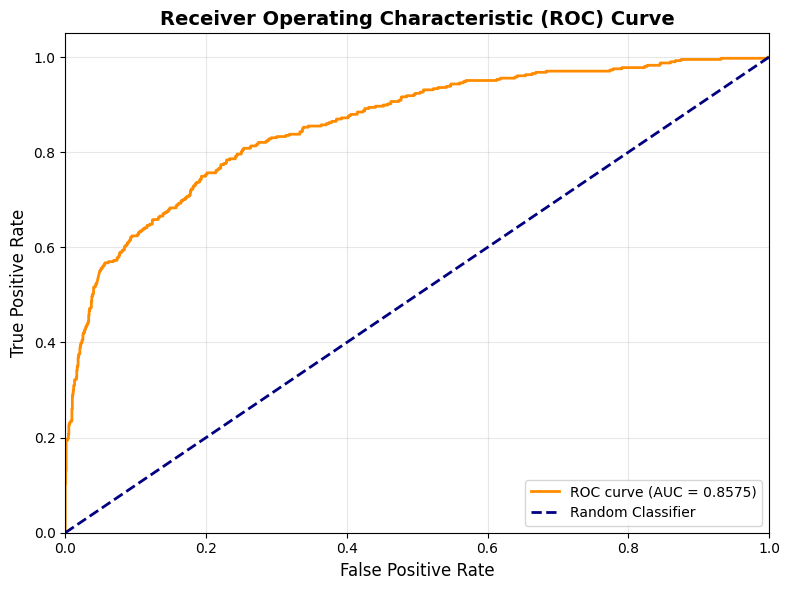

In [27]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Discussion of important metrics for churn prediction
print("METRICS IMPORTANCE FOR CHURN PREDICTION")
print("="*60)
print("""
For customer churn prediction, the most important metrics are:

1. RECALL (Sensitivity) - MOST IMPORTANT
   - Measures: What % of actual churners did we identify?
   - Why important: Missing a churner (False Negative) is costly
   - A churner we miss will leave, causing revenue loss
   - Current Recall: {:.2f}%

2. PRECISION
   - Measures: Of predicted churners, what % actually churned?
   - Why important: Targeting non-churners wastes retention budget
   - Current Precision: {:.2f}%

3. F1-SCORE
   - Harmonic mean of Precision and Recall
   - Balances both concerns
   - Current F1: {:.2f}%

4. ROC-AUC
   - Measures model's ability to discriminate between classes
   - Useful for comparing models
   - Current AUC: {:.4f}

BUSINESS RECOMMENDATION:
- In churn prediction, prioritize RECALL over precision
- It's better to contact a customer who won't churn (false positive)
  than to miss a customer who will churn (false negative)
- Consider lowering the classification threshold from 0.5 to increase recall
""".format(recall*100, precision*100, f1*100, roc_auc))

METRICS IMPORTANCE FOR CHURN PREDICTION

For customer churn prediction, the most important metrics are:

1. RECALL (Sensitivity) - MOST IMPORTANT
   - Measures: What % of actual churners did we identify?
   - Why important: Missing a churner (False Negative) is costly
   - A churner we miss will leave, causing revenue loss
   - Current Recall: 43.24%

2. PRECISION
   - Measures: Of predicted churners, what % actually churned?
   - Why important: Targeting non-churners wastes retention budget
   - Current Precision: 78.57%

3. F1-SCORE
   - Harmonic mean of Precision and Recall
   - Balances both concerns
   - Current F1: 55.78%

4. ROC-AUC
   - Measures model's ability to discriminate between classes
   - Useful for comparing models
   - Current AUC: 0.8575

BUSINESS RECOMMENDATION:
- In churn prediction, prioritize RECALL over precision
- It's better to contact a customer who won't churn (false positive)
  than to miss a customer who will churn (false negative)
- Consider lowering the

---
# 6. Visualization and Reporting (Rubric Task 5: 8 pts)

**Visualizations:**
1. Training history (loss and accuracy curves)
2. Predictions with confidence scores
3. Hyperparameter comparison charts
4. Final summary report

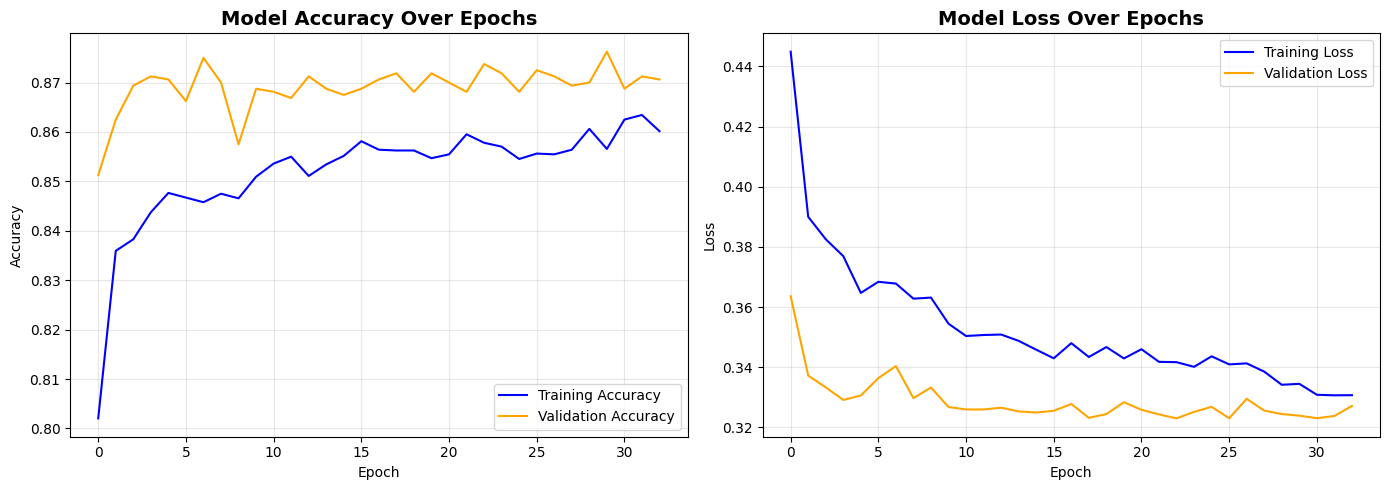

In [29]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(final_history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0].plot(final_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(final_history.history['loss'], label='Training Loss', color='blue')
axes[1].plot(final_history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

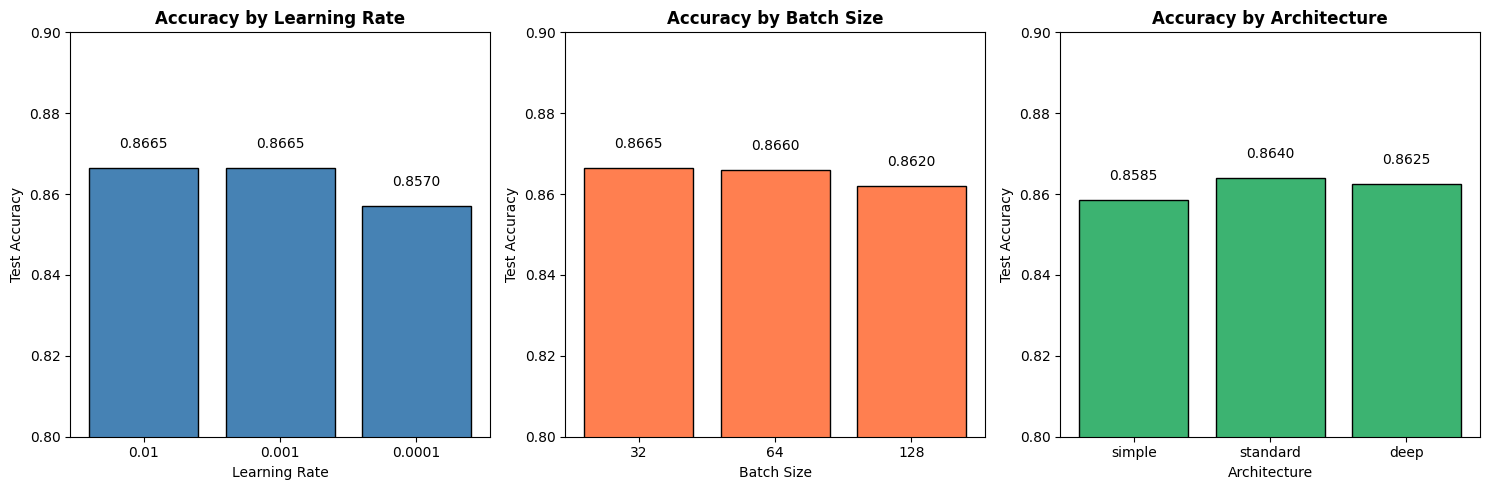

In [30]:
# Hyperparameter comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Learning rate comparison
lrs = list(lr_results.keys())
lr_accs = [lr_results[lr]['accuracy'] for lr in lrs]
axes[0].bar([str(lr) for lr in lrs], lr_accs, color='steelblue', edgecolor='black')
axes[0].set_title('Accuracy by Learning Rate', fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim([0.8, 0.9])
for i, v in enumerate(lr_accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# Batch size comparison
batches = list(batch_results.keys())
batch_accs = [batch_results[b]['accuracy'] for b in batches]
axes[1].bar([str(b) for b in batches], batch_accs, color='coral', edgecolor='black')
axes[1].set_title('Accuracy by Batch Size', fontweight='bold')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim([0.8, 0.9])
for i, v in enumerate(batch_accs):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# Architecture comparison
archs = list(arch_results.keys())
arch_accs = [arch_results[a]['accuracy'] for a in archs]
axes[2].bar(archs, arch_accs, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Accuracy by Architecture', fontweight='bold')
axes[2].set_xlabel('Architecture')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_ylim([0.8, 0.9])
for i, v in enumerate(arch_accs):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# Visualize sample predictions with confidence scores
print("SAMPLE PREDICTIONS WITH CONFIDENCE SCORES")
print("="*60)

# Get sample predictions
sample_indices = np.random.choice(len(X_test), 10, replace=False)
sample_X = X_test_scaled[sample_indices]
sample_y_true = y_test.iloc[sample_indices].values
sample_proba = final_model.predict(sample_X, verbose=0).flatten()
sample_pred = (sample_proba > 0.5).astype(int)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(sample_indices))
colors = ['green' if p == t else 'red' for p, t in zip(sample_pred, sample_y_true)]

bars = ax.bar(x_pos, sample_proba, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(y=0.5, color='black', linestyle='--', label='Threshold (0.5)')

ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Churn Probability', fontsize=12)
ax.set_title('Sample Predictions with Confidence Scores\n(Green=Correct, Red=Incorrect)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'#{i}' for i in sample_indices])
ax.set_ylim([0, 1])
ax.legend()

# Add annotations
for i, (prob, true, pred) in enumerate(zip(sample_proba, sample_y_true, sample_pred)):
    label = f'P:{prob:.2f}\nT:{true}'
    ax.text(i, prob + 0.05, label, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed table
print("\nDetailed Sample Predictions:")
print("-" * 60)
print(f"{'Index':<8} {'True':<8} {'Predicted':<12} {'Probability':<12} {'Correct':<8}")
print("-" * 60)
for idx, true, pred, prob in zip(sample_indices, sample_y_true, sample_pred, sample_proba):
    correct = 'Yes' if true == pred else 'No'
    true_label = 'Churned' if true == 1 else 'Stayed'
    pred_label = 'Churned' if pred == 1 else 'Stayed'
    print(f"{idx:<8} {true_label:<8} {pred_label:<12} {prob:<12.4f} {correct:<8}")


Detailed Sample Predictions:
------------------------------------------------------------
Index    True     Predicted    Probability  Correct 
------------------------------------------------------------
1860     Churned  Stayed       0.4061       No      
353      Churned  Stayed       0.2074       No      
1333     Churned  Churned      0.6145       Yes     
905      Churned  Stayed       0.3670       No      
1289     Stayed   Stayed       0.0886       Yes     
1273     Stayed   Stayed       0.1006       Yes     
938      Stayed   Stayed       0.0322       Yes     
1731     Churned  Stayed       0.4296       No      
65       Stayed   Stayed       0.0544       Yes     
1323     Stayed   Stayed       0.0844       Yes     


In [32]:
# Final Summary Report
print("="*70)
print("                    FINAL SUMMARY REPORT")
print("="*70)
print("""
PROJECT: Bank Customer Churn Prediction using Artificial Neural Network
""")

print("1. DATA PREPROCESSING")
print("-"*70)
print(f"   - Original dataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"   - Removed features: RowNumber, CustomerId, Surname")
print(f"   - Encoded: Gender (Label), Geography (One-Hot)")
print(f"   - Final features: {X.shape[1]}")
print(f"   - Train/Test split: 80%/20% (stratified)")
print(f"   - Scaling: StandardScaler applied")

print("\n2. MODEL ARCHITECTURE")
print("-"*70)
print(f"   - Type: Sequential Artificial Neural Network")
print(f"   - Best Architecture: {best_arch}")
print(f"   - Layers: Dense + BatchNormalization + Dropout")
print(f"   - Activation: ReLU (hidden), Sigmoid (output)")
print(f"   - Regularization: Dropout (0.2-0.4), BatchNormalization")

print("\n3. TRAINING CONFIGURATION")
print("-"*70)
print(f"   - Best Learning Rate: {best_lr}")
print(f"   - Best Batch Size: {best_batch}")
print(f"   - Optimizer: Adam")
print(f"   - Loss Function: Binary Crossentropy")
print(f"   - Callbacks: EarlyStopping, ReduceLROnPlateau")

print("\n4. PERFORMANCE METRICS")
print("-"*70)
print(f"   - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")
print(f"   - ROC-AUC:   {roc_auc:.4f}")

print("\n5. KEY FINDINGS")
print("-"*70)
print("""
   - The ANN achieves good accuracy in predicting customer churn
   - Recall is important for this task (identifying churners)
   - BatchNormalization and Dropout help prevent overfitting
   - The 'standard' architecture balances complexity and performance
   - Dataset imbalance (20% churn rate) affects model predictions
""")

print("\n6. RECOMMENDATIONS")
print("-"*70)
print("""
   - Consider using class weights to handle imbalance
   - Tune classification threshold for business needs
   - Feature engineering could improve predictions
   - Regular retraining as customer behavior changes
""")
print("="*70)

                    FINAL SUMMARY REPORT

PROJECT: Bank Customer Churn Prediction using Artificial Neural Network

1. DATA PREPROCESSING
----------------------------------------------------------------------
   - Original dataset: 10000 samples, 14 features
   - Removed features: RowNumber, CustomerId, Surname
   - Encoded: Gender (Label), Geography (One-Hot)
   - Final features: 11
   - Train/Test split: 80%/20% (stratified)
   - Scaling: StandardScaler applied

2. MODEL ARCHITECTURE
----------------------------------------------------------------------
   - Type: Sequential Artificial Neural Network
   - Best Architecture: standard
   - Layers: Dense + BatchNormalization + Dropout
   - Activation: ReLU (hidden), Sigmoid (output)
   - Regularization: Dropout (0.2-0.4), BatchNormalization

3. TRAINING CONFIGURATION
----------------------------------------------------------------------
   - Best Learning Rate: 0.01
   - Best Batch Size: 32
   - Optimizer: Adam
   - Loss Function: Binary